# **Task 07 — Graph Explainability and Embedding Analysis**
## **CCS4354 — Tensors and Graphs | OGBN-Arxiv**

This notebook interprets the behavior of the three trained models from
Tasks 04–06 (GCN, GraphSAGE, and the bonus GAT architecture) and
explains *why* each model makes its predictions.

### **Section 1 — Setup, load data, models, and checkpoints**

In [1]:
import sys
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def find_project_root(marker: str = "requirements.txt") -> Path:
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not locate project root (missing {marker})")

PROJECT_ROOT = find_project_root()
sys.path.append(str(PROJECT_ROOT / "src"))

from models.gnn_models import GCN, GraphSAGE, GAT

print("Imported GCN, GraphSAGE, GAT from src/models/gnn_models.py")

Imported GCN, GraphSAGE, GAT from src/models/gnn_models.py


### **Section 2 — Load data and trained model weights**

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "processed_data.pkl"
CONFIG_PATH = PROJECT_ROOT / "models_checkpoints" / "model_config.json"
CHECKPOINT_DIR = PROJECT_ROOT / "models_checkpoints"

with open(DATA_PATH, "rb") as f:
    processed = pickle.load(f)

with open(CONFIG_PATH) as f:
    model_config = json.load(f)

features = processed["features"]
labels = processed["labels"].view(-1)
edge_index = to_undirected(processed["edge_index"].long(), num_nodes=features.shape[0])
test_idx = processed["test_idx"].view(-1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
graph_data = Data(x=features.float(), edge_index=edge_index, y=labels.long()).to(DEVICE)


def build_and_load(model_class, config_entry, checkpoint_path, hidden_channels_key_shape=None):
    """
    Rebuilds a model from config, but verifies/corrects hidden_channels
    against the actual checkpoint before loading — protects against a
    stale model_config.json not matching what was actually trained
    (e.g. after hyperparameter tuning changed the final architecture).
    """
    state_dict = torch.load(checkpoint_path, map_location=DEVICE)
    config = {k: v for k, v in config_entry.items() if k != "class"}

    if hidden_channels_key_shape is not None:
        actual_hidden = state_dict[hidden_channels_key_shape[0]].shape[hidden_channels_key_shape[1]]
        if actual_hidden != config.get("hidden_channels"):
            print(f"  [fix] {model_class.__name__}: config said "
                  f"hidden_channels={config.get('hidden_channels')}, "
                  f"checkpoint actually has {actual_hidden} — using checkpoint value")
            config["hidden_channels"] = actual_hidden

    model = model_class(**config).to(DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    return model


print("Loading GCN...")
gcn_model = build_and_load(
    GCN, model_config["gcn"], CHECKPOINT_DIR / "gcn_final.pt",
    hidden_channels_key_shape=("bn1.weight", 0)
)

print("Loading GraphSAGE...")
sage_model = build_and_load(
    GraphSAGE, model_config["graphsage"], CHECKPOINT_DIR / "graphsage_final.pt",
    hidden_channels_key_shape=("bn1.weight", 0)
)

print("Loading GAT...")
gat_model = build_and_load(
    GAT, model_config["gat"], CHECKPOINT_DIR / "gat_final.pt",
    hidden_channels_key_shape=("conv1.att_src", 2)
)

print("\nLoaded trained GCN, GraphSAGE, and GAT weights.")

Loading GCN...
Loading GraphSAGE...
Loading GAT...

Loaded trained GCN, GraphSAGE, and GAT weights.


### **Section 3 — Option B: Node Embedding Visualization (PCA + t-SNE)**

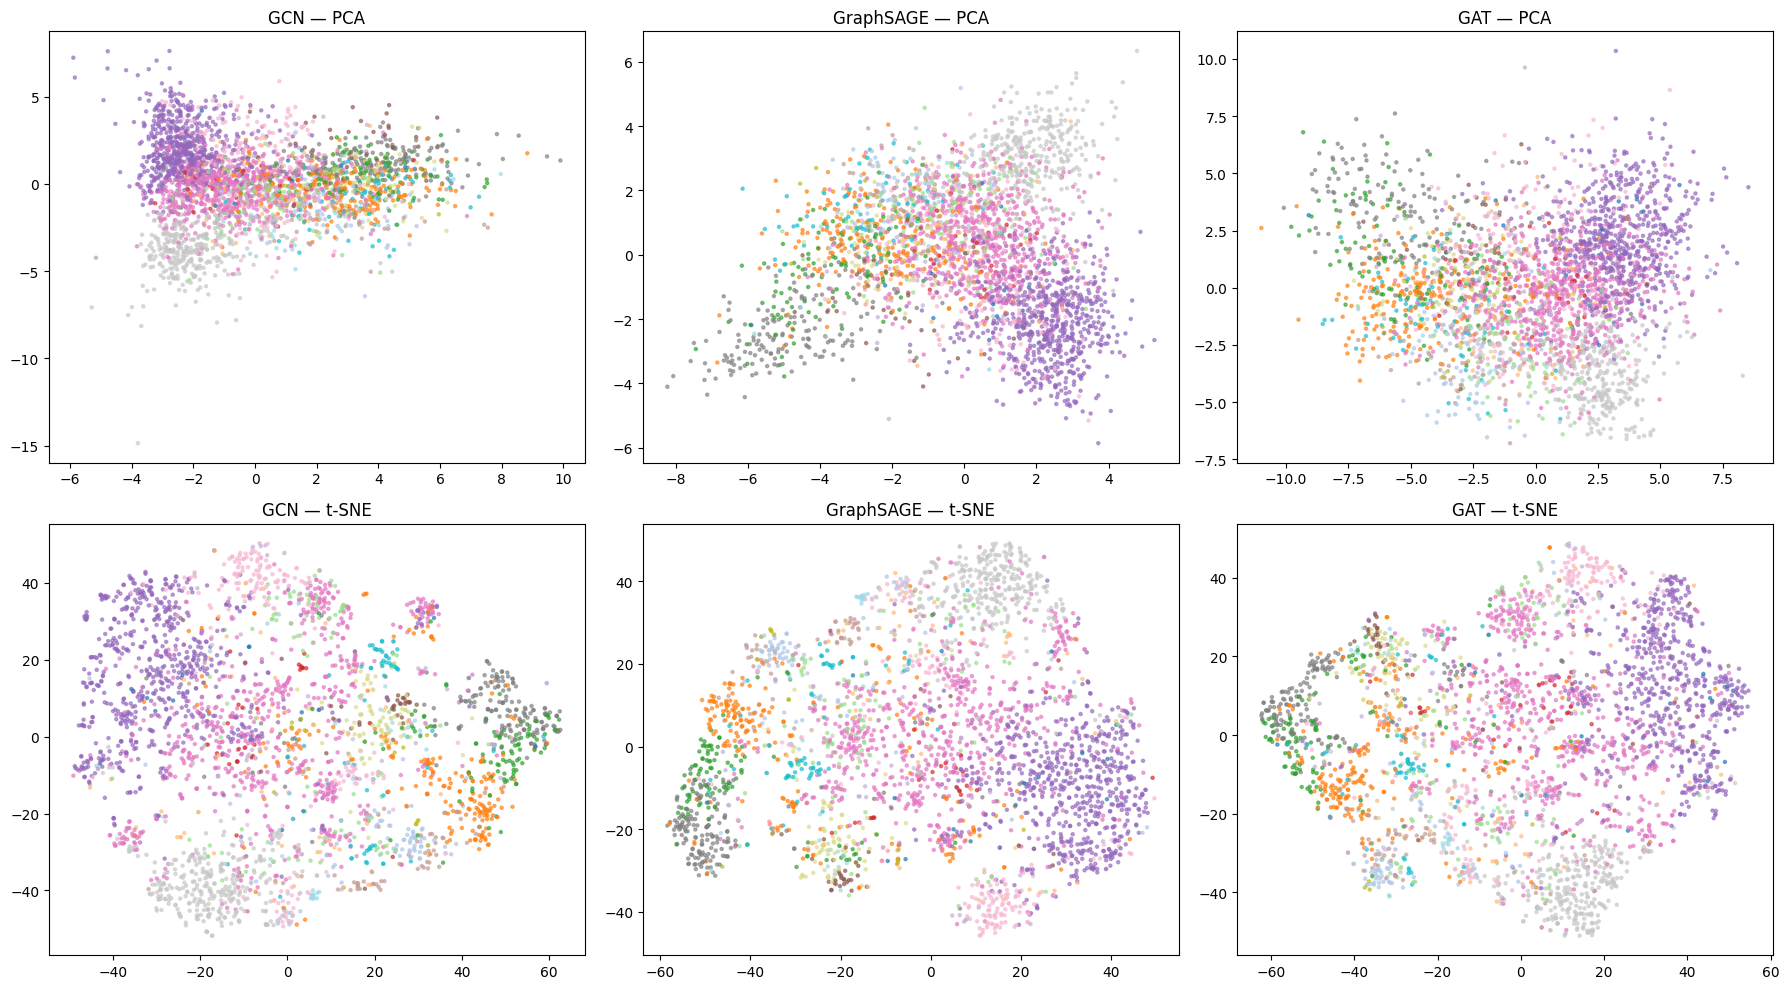

Embedding visualization saved to reports/embedding_visualization.png


In [3]:
SAMPLE_SIZE = 3000  # full graph is too dense to visualize meaningfully
np.random.seed(42)
sample_idx = np.random.choice(test_idx.cpu().numpy(), SAMPLE_SIZE, replace=False)

models_dict = {"GCN": gcn_model, "GraphSAGE": sage_model, "GAT": gat_model}
embeddings_dict = {}

with torch.no_grad():
    for name, model in models_dict.items():
        emb = model.get_embeddings(graph_data.x, graph_data.edge_index)
        embeddings_dict[name] = emb[sample_idx].cpu().numpy()

sample_labels = graph_data.y[sample_idx].cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, emb) in enumerate(embeddings_dict.items()):
    # PCA
    pca_result = PCA(n_components=2, random_state=42).fit_transform(emb)
    sc1 = axes[0, col].scatter(pca_result[:, 0], pca_result[:, 1],
                                 c=sample_labels, cmap="tab20", s=5, alpha=0.6)
    axes[0, col].set_title(f"{name} — PCA")

    # t-SNE
    tsne_result = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(emb)
    axes[1, col].scatter(tsne_result[:, 0], tsne_result[:, 1],
                          c=sample_labels, cmap="tab20", s=5, alpha=0.6)
    axes[1, col].set_title(f"{name} — t-SNE")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "embedding_visualization.png", dpi=300)
plt.show()

print("Embedding visualization saved to reports/embedding_visualization.png")

### **Section 4 — Option C: Attention Weight Analysis (GAT)**

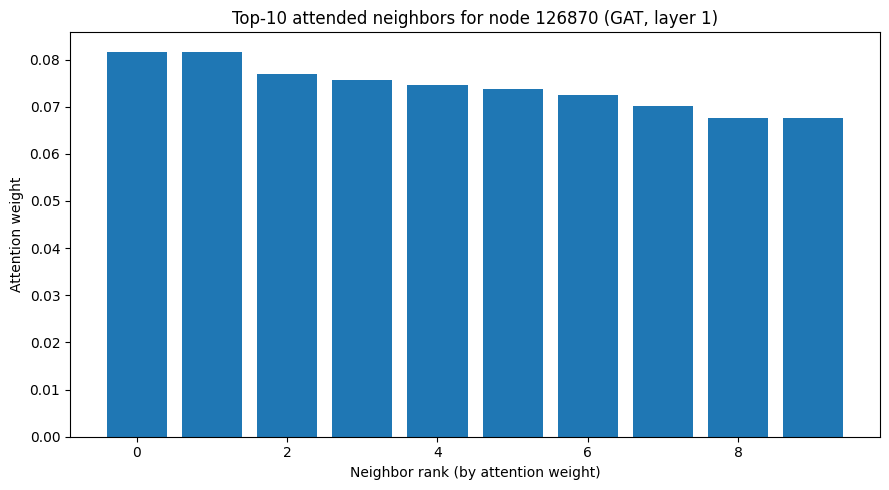

Node 126870 has 14 neighbors in layer 1.
Attention weight range: 0.0598 to 0.0817
Attention weight std: 0.0061

A higher spread (std) indicates GAT is genuinely discriminating between
neighbors, rather than treating them all equally (which would look like
GraphSAGE's or GCN's fixed/uniform aggregation).


In [4]:
with torch.no_grad():
    logits, (edge_idx_1, alpha_1), (edge_idx_2, alpha_2) = gat_model.forward_with_attention(
        graph_data.x, graph_data.edge_index
    )

# Average attention across heads (layer 1 is multi-head)
alpha_1_avg = alpha_1.mean(dim=1).cpu().numpy()

# Pick one test node to inspect closely
example_node = int(sample_idx[0])
mask = (edge_idx_1[1].cpu().numpy() == example_node)
neighbor_nodes = edge_idx_1[0].cpu().numpy()[mask]
neighbor_attention = alpha_1_avg[mask]

order = np.argsort(-neighbor_attention)
top_k = 10

plt.figure(figsize=(9, 5))
plt.bar(range(min(top_k, len(order))), neighbor_attention[order][:top_k])
plt.xlabel("Neighbor rank (by attention weight)")
plt.ylabel("Attention weight")
plt.title(f"Top-{top_k} attended neighbors for node {example_node} (GAT, layer 1)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "gat_attention_weights.png", dpi=300)
plt.show()

print(f"Node {example_node} has {mask.sum()} neighbors in layer 1.")
print(f"Attention weight range: {neighbor_attention.min():.4f} to {neighbor_attention.max():.4f}")
print(f"Attention weight std: {neighbor_attention.std():.4f}")
print("\nA higher spread (std) indicates GAT is genuinely discriminating between")
print("neighbors, rather than treating them all equally (which would look like")
print("GraphSAGE's or GCN's fixed/uniform aggregation).")

### **Section 5 (Bonus) — Option A: Feature Importance Analysis**

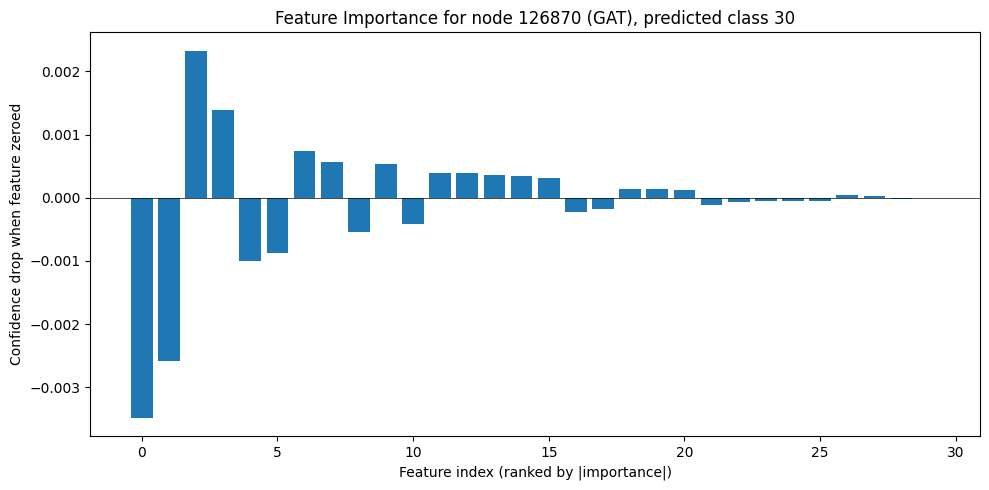

Baseline prediction confidence: 0.8577
Most influential feature index: 48, confidence drop: -0.0035


In [5]:
def feature_importance_via_ablation(model, graph_data, node_idx, n_features_to_test=20):
    """
    Measures how much each input feature dimension affects a node's
    prediction confidence, by zeroing it out and observing the drop
    in predicted-class probability. A simple, model-agnostic method
    (works identically for GCN, GraphSAGE, and GAT).
    """
    model.eval()
    with torch.no_grad():
        baseline_logits = model(graph_data.x, graph_data.edge_index)
        baseline_probs = torch.softmax(baseline_logits[node_idx], dim=0)
        predicted_class = baseline_probs.argmax().item()
        baseline_confidence = baseline_probs[predicted_class].item()

    importances = []
    feature_dim = graph_data.x.shape[1]
    test_features = np.random.choice(feature_dim, n_features_to_test, replace=False)

    for feat_idx in test_features:
        x_ablated = graph_data.x.clone()
        x_ablated[node_idx, feat_idx] = 0.0

        with torch.no_grad():
            ablated_logits = model(x_ablated, graph_data.edge_index)
            ablated_probs = torch.softmax(ablated_logits[node_idx], dim=0)
            ablated_confidence = ablated_probs[predicted_class].item()

        importances.append(baseline_confidence - ablated_confidence)

    return test_features, np.array(importances), predicted_class, baseline_confidence


test_features, importances, pred_class, confidence = feature_importance_via_ablation(
    gat_model, graph_data, example_node, n_features_to_test=30
)

order = np.argsort(-np.abs(importances))

plt.figure(figsize=(10, 5))
plt.bar(range(len(order)), importances[order])
plt.xlabel("Feature index (ranked by |importance|)")
plt.ylabel("Confidence drop when feature zeroed")
plt.title(f"Feature Importance for node {example_node} (GAT), predicted class {pred_class}")
plt.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "feature_importance.png", dpi=300)
plt.show()

print(f"Baseline prediction confidence: {confidence:.4f}")
print(f"Most influential feature index: {test_features[order[0]]}, "
      f"confidence drop: {importances[order[0]]:.4f}")

### **Section 6 (Bonus) — Option D: Neighborhood Influence Analysis**

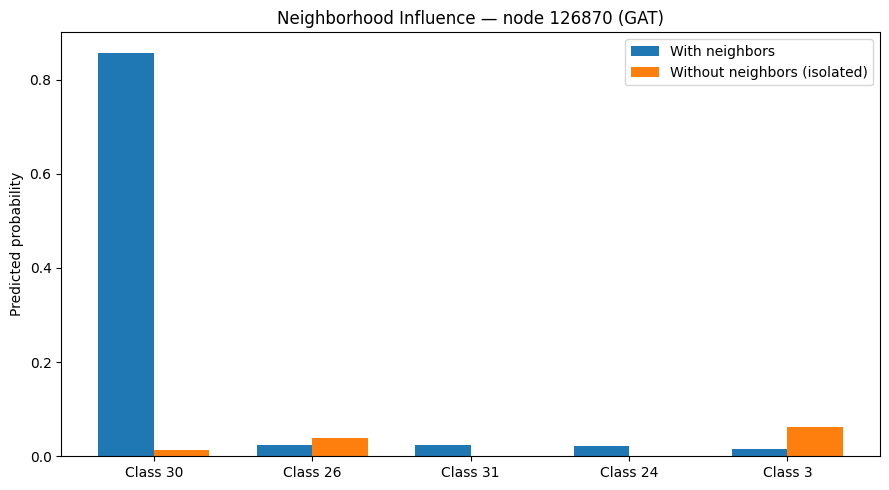

Total probability shift caused by removing neighbors: 0.9322
A larger shift means the model relies heavily on graph structure,
not just the node's own features, to make its prediction.


In [6]:
def neighborhood_influence(model, graph_data, node_idx):
    """
    Measures how much a node's prediction depends on its neighbors
    at all, by comparing the prediction using the real graph vs. an
    isolated version of the node (no edges) — i.e. features alone.
    """
    model.eval()
    with torch.no_grad():
        full_logits = model(graph_data.x, graph_data.edge_index)
        full_probs = torch.softmax(full_logits[node_idx], dim=0)

        # Isolate the node: remove all its edges
        edge_mask = (graph_data.edge_index[0] != node_idx) & (graph_data.edge_index[1] != node_idx)
        isolated_edge_index = graph_data.edge_index[:, edge_mask]

        isolated_logits = model(graph_data.x, isolated_edge_index)
        isolated_probs = torch.softmax(isolated_logits[node_idx], dim=0)

    return full_probs.cpu().numpy(), isolated_probs.cpu().numpy()


full_probs, isolated_probs = neighborhood_influence(gat_model, graph_data, example_node)

top_classes = np.argsort(-full_probs)[:5]

plt.figure(figsize=(9, 5))
x_pos = np.arange(len(top_classes))
width = 0.35
plt.bar(x_pos - width/2, full_probs[top_classes], width, label="With neighbors")
plt.bar(x_pos + width/2, isolated_probs[top_classes], width, label="Without neighbors (isolated)")
plt.xticks(x_pos, [f"Class {c}" for c in top_classes])
plt.ylabel("Predicted probability")
plt.title(f"Neighborhood Influence — node {example_node} (GAT)")
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "neighborhood_influence.png", dpi=300)
plt.show()

influence_score = np.abs(full_probs - isolated_probs).sum() / 2
print(f"Total probability shift caused by removing neighbors: {influence_score:.4f}")
print("A larger shift means the model relies heavily on graph structure,")
print("not just the node's own features, to make its prediction.")